# Imports e conexão

In [11]:
import Connection as conn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # só para não ficar reclamando
warnings.filterwarnings("ignore")

In [16]:
headers = conn.get_conn('matheus_root','server@Database')
df, df_tratado = conn.get_dataset_completo(headers)
print(f'DF bruto: {df.shape[0]} registros, {df.shape[1]} colunas')
print(f'DF tratado: {df_tratado.shape[0]} registros, {df_tratado.shape[1]} colunas')
df.head()

DF bruto: 1460 registros, 24 colunas
DF tratado: 1460 registros, 24 colunas


,id,ms_subclass,ms_zoning,lot_area,street,neighborhood,overall_qual,overall_cond,year_built,year_remod_add,...,kitchen_abvgr,totrms_abvgrd,garage_cars,garage_area,sale_price,house_age,remod_age,total_bath,area_per_room,price_category
0,1,60,RL,8450,Pave,CollgCr,7,5,2003,2003,...,1,8,2.0,548.0,208500,21,21,2.5,213.750000,1
1,2,20,RL,9600,Pave,Veenker,6,8,1976,1976,...,1,6,2.0,460.0,181500,48,48,2.0,210.333333,1
2,3,60,RL,11250,Pave,CollgCr,7,5,2001,2002,...,1,6,2.0,608.0,223500,23,22,2.5,297.666667,1
3,4,70,RL,9550,Pave,Crawfor,7,5,1915,1970,...,1,7,3.0,642.0,140000,109,54,1.0,245.285714,0
4,5,60,RL,14260,Pave,NoRidge,8,5,2000,2000,...,1,9,3.0,836.0,250000,24,24,2.5,244.222222,1


# 1. Análise Exploratória EDA
### 1.1 Visão geral do dataset

In [18]:
print('Tipos de variáveis')
print('\nVariáveis numéricas:', df.select_dtypes(include='number').columns.tolist())
print('\nVariáveis categóricas:', df.select_dtypes(include='object').columns.tolist())

Tipos de variáveis

Variáveis numéricas: ['id', 'ms_subclass', 'lot_area', 'overall_qual', 'overall_cond', 'year_built', 'year_remod_add', 'gr_liv_area', 'full_bath', 'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'totrms_abvgrd', 'garage_cars', 'garage_area', 'sale_price', 'house_age', 'remod_age', 'total_bath', 'area_per_room', 'price_category']

Variáveis categóricas: ['ms_zoning', 'street', 'neighborhood']


### 1.2 Valores Faltantes

In [19]:
missing = conn.get_missing(headers)
missing_df = pd.DataFrame(missing['missing_values']).T
missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing_pct', ascending=True)

if missing_df.empty:
    print("Não tem valores faltantes")
else:
    print(missing_df)
    fig, ax = plt.subplots()
    missing_df['missing_pct'].plot(kind='bar', ax=ax, color='salmon')
    ax.set_title('Percentual de Valores Faltantes por Coluna')
    ax.set_ylabel('% Faltante')
    ax.set_xlabel('Coluna')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Não tem valores faltantes


### 1.3 Distruibuição do preço de venda

=== Distribuição do Preço de Venda ===
  min: $34,900.00
  max: $755,000.00
  media: $180,921.20
  q1: $129,975.00
  mediana: $163,000.00
  q3: $214,000.00


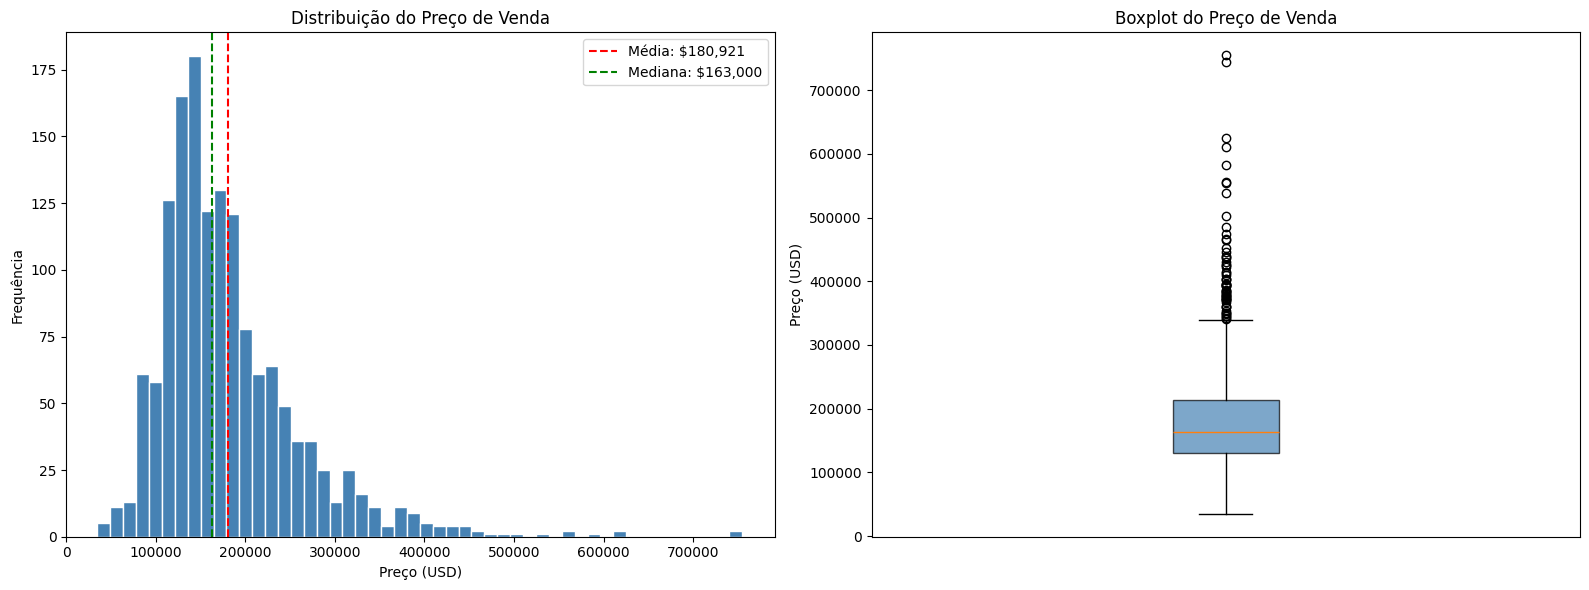

In [26]:
dist = conn.get_distribution(headers)['distribuicao_preco']
print("=== Distribuição do Preço de Venda ===")
for k, v in dist.items():
    print(f"  {k}: ${v:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
axes[0].hist(df['sale_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(dist['media'], color='red', linestyle='--', label=f"Média: ${dist['media']:,.0f}")
axes[0].axvline(dist['mediana'], color='green', linestyle='--', label=f"Mediana: ${dist['mediana']:,.0f}")
axes[0].set_title('Distribuição do Preço de Venda')
axes[0].set_xlabel('Preço (USD)')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='x')
axes[0].set_xlim(left=0)

# Boxplot
axes[1].boxplot(df['sale_price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot do Preço de Venda')
axes[1].set_ylabel('Preço (USD)')
axes[1].set_xticks([])
axes[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)


plt.tight_layout()
plt.show()

### 1.4 Correlações com o Preço de Venda

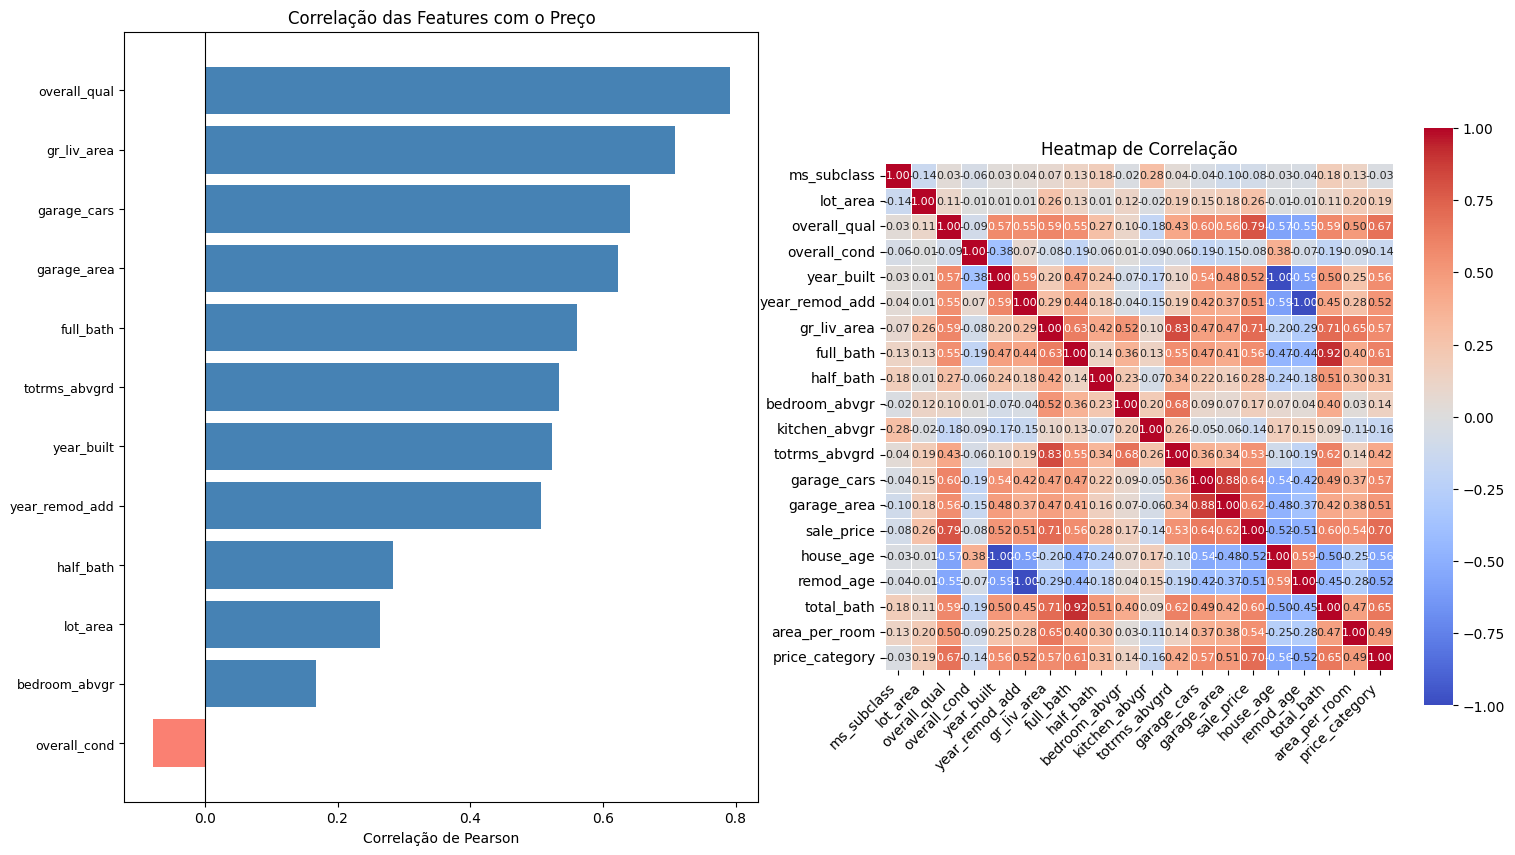

<Figure size 640x480 with 0 Axes>

In [25]:
corr_data = conn.get_correlations(headers)
corr_series = pd.Series(corr_data['correlacao_com_preco']).drop('sale_price')

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Ordena por correlação para melhor leitura
corr_series = corr_series.sort_values()

# Barras de correlação
colors = ['steelblue' if v > 0 else 'salmon' for v in corr_series.values]
axes[0].barh(corr_series.index, corr_series.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlação das Features com o Preço')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].tick_params(axis='y', labelsize=9)

# Heatmap
numeric_df = df.select_dtypes(include='number').drop(columns=['id'], errors='ignore')
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], annot_kws={'size': 8}, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.75})
axes[1].set_title('Heatmap de Correlação')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.setp(axes[1].get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()



### 1.5 Distribuição das Variáveis Mais Relevantes

In [ ]:
top_features = corr_series.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['sale_price'], alpha=0.5, color='steelblue', s=20)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('sale_price')
    axes[i].set_title(f'{feat} vs Preço (corr: {corr_series[feat]:.2f})')

plt.suptitle('Top Features vs Preço de Venda', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 1.6 Preço por Bairro

In [ ]:
preco_bairro = df.groupby('neighborhood')['sale_price'].median().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
preco_bairro.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Preço Mediano por Bairro')
plt.xlabel('Bairro')
plt.ylabel('Preço Mediano (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


---
## 2. Feature Engineering
### 2.1 Novas Features Criadas

In [ ]:
print("=== Novas Features ===")
print("""
  house_age    = 2024 - year_built      → Idade da casa
  remod_age    = 2024 - year_remod_add  → Anos desde a última reforma
  total_bath   = full_bath + 0.5*half_bath → Total de banheiros
  area_per_room = gr_liv_area / totrms_abvgrd → Área média por cômodo
  price_category = 1 se acima da mediana, 0 caso contrário
""")

df['house_age'] = 2024 - df['year_built']
df['remod_age'] = 2024 - df['year_remod_add']
df['total_bath'] = df['full_bath'] + 0.5 * df['half_bath']
df['area_per_room'] = df['gr_liv_area'] / df['totrms_abvgrd']
df['price_category'] = (df['sale_price'] > df['sale_price'].median()).astype(int)

novas = ['house_age', 'remod_age', 'total_bath', 'area_per_room', 'price_category']
df[novas].describe().round(2)


### 2.2 Distribuição das Novas Features

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(['house_age', 'remod_age', 'total_bath', 'area_per_room']):
    axes[i].hist(df[feat].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
    axes[i].set_title(f'Distribuição: {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição das Novas Features', fontsize=14)
plt.tight_layout()
plt.show()


### 2.3 Normalização das Variáveis Numéricas

In [ ]:
norm_minmax = conn.get_normalized(headers, method='minmax')
norm_standard = conn.get_normalized(headers, method='standard')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

norm_minmax.boxplot(ax=axes[0])
axes[0].set_title('Normalização MinMax (0-1)')
axes[0].set_xticklabels(norm_minmax.columns, rotation=45, ha='right')

norm_standard.boxplot(ax=axes[1])
axes[1].set_title('Normalização Standard (Z-score)')
axes[1].set_xticklabels(norm_standard.columns, rotation=45, ha='right')

plt.suptitle('Comparação dos Métodos de Normalização', fontsize=13)
plt.tight_layout()
plt.show()


### 2.4 Encoding das Variáveis Categóricas

In [ ]:
encoded = conn.get_encoded(headers)
print("=== Mapeamento de Encoding ===")
for col, mapping in encoded['mapeamento'].items():
    print(f"
{col}: {len(mapping)} categorias únicas")
    print(dict(list(mapping.items())[:5]), "...")


---
## 3. Visualização dos Resultados dos Modelos
### 3.1 Regressão

In [ ]:
reg_simples = conn.get_regression_simple(headers)
reg_multipla = conn.get_regression_multiple(headers)

modelos = ['Regressão Simples', 'Regressão Múltipla']
rmse = [reg_simples['metricas']['RMSE'], reg_multipla['metricas']['RMSE']]
r2 = [reg_simples['metricas']['R2'], reg_multipla['metricas']['R2']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(modelos, rmse, color=['salmon', 'steelblue'])
axes[0].set_title('RMSE — Menor é Melhor')
axes[0].set_ylabel('RMSE (USD)')
for i, v in enumerate(rmse):
    axes[0].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

axes[1].bar(modelos, r2, color=['salmon', 'steelblue'])
axes[1].set_title('R² — Maior é Melhor')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
for i, v in enumerate(r2):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Comparação dos Modelos de Regressão', fontsize=13)
plt.tight_layout()
plt.show()


### 3.2 Classificação

In [ ]:
knn = conn.get_classification_knn(headers)
rf = conn.get_classification_rf(headers)

metricas = ['accuracy', 'precision', 'recall', 'f1_score']
knn_vals = [knn['metricas'][m] for m in metricas]
rf_vals = [rf['metricas'][m] for m in metricas]

x = range(len(metricas))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar([i - width/2 for i in x], knn_vals, width, label='KNN', color='steelblue')
axes[0].bar([i + width/2 for i in x], rf_vals, width, label='Random Forest', color='mediumseagreen')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(metricas)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Métricas de Classificação')
axes[0].legend()

cm = rf['matriz_confusao']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Baixo', 'Alto'],
            yticklabels=['Baixo', 'Alto'])
axes[1].set_title('Matriz de Confusão — Random Forest')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.suptitle('Resultados da Classificação', fontsize=13)
plt.tight_layout()
plt.show()
